### -> “Binary Classification of Iris Flowers Using Perceptron Algorithm.”

## Table of Contents
- [Introduction](#Introduction)
- [Import Libraries](#Import-Libraries)
- [Load and Explore Data](#Load-and-Explore-Data)
- [Data Preprocessing](#Data-Preprocessing)
- [Perceptron Implementation](#Perceptron-Implementation)
- [Model Training](#Model-Training)
- [Model Evaluation](#Model-Evaluation)
- [Visualizations](#Visualizations)
- [Conclusion](#Conclusion)

## Introduction

### What is a Perceptron?
A **Perceptron** is the simplest form of artificial neural network, designed for binary classification tasks. It works by finding a linear decision boundary that separates two classes in the feature space.

**Mathematical Formula:**
The Perceptron computes: $f(x) = \mathrm{sign}(w^T x + b) $

Where:
- $ w $ = weight vector
- $ x $ = input features
- $ b $ = bias term
- Output: 1 if $w^T x + b \geq 0 $, else 0

### Why Iris Dataset?
I chose the **Iris dataset** for this project because:
- **Setosa vs Non-Setosa** (Versicolor & Virginica) forms a **linearly separable** binary classification problem
- Setosa flowers have distinctly different petal measurements, making them easy to classify
- Perfect for demonstrating Perceptron's effectiveness on linearly separable data

### Project Objective
Build a Perceptron model from scratch (or using sklearn) to classify Iris Setosa (Class 1) vs Non-Setosa (Class 0) with high accuracy using only petal length and petal width features.

## Import Libraries

In [1]:
# Step 1 - Import basic and necessary Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from warnings import filterwarnings
filterwarnings('ignore')

In [2]:
import matplotlib
%matplotlib inline

## Load and Explore Data

In [3]:
# Step 2 - Load dataset

from sklearn.datasets import load_iris
iris = load_iris()

print("\nData shape:", iris.data.shape)
print("\nFeature names:", iris.feature_names)
print ("\nTarget names:", iris.target_names)


Data shape: (150, 4)

Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Target names: ['setosa' 'versicolor' 'virginica']


**Dataset Overview:**
- The Iris dataset contains **150 samples** with **4 features** measuring sepal and petal dimensions
- Three target classes: **Setosa**, **Versicolor**, and **Virginica**
- For binary classification, we'll encode: **Setosa = 1** and **Non-Setosa (Versicolor + Virginica) = 0**
- We'll use only **petal length** and **petal width** as these two features best separate Setosa from others

## Data Preprocessing

In [4]:
# Step 3 - Define feature and Target

# Select only petal features (columns 2 and 3)
X = iris.data[:, [2, 3]]   # petal length, petal width

# Binary target: 1 if Setosa, 0 otherwise
y = (iris.target == 0).astype(int)

print(f"Feature shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Setosa samples: {sum(y)}, Non-Setosa samples: {len(y) - sum(y)}")

Feature shape: (150, 2)
Target shape: (150,)
Setosa samples: 50, Non-Setosa samples: 100


**Preprocessing Steps:**
- Selected **petal length** and **petal width** (2 features) for 2D visualization
- Created binary labels: **Setosa (1)** vs **Non-Setosa (0)**
- Dataset is balanced: **50 Setosa** and **100 Non-Setosa** samples

In [5]:
# Step 4 - Split data

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = 42,
    stratify=y
)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((120, 2), (30, 2), (120,), (30,))

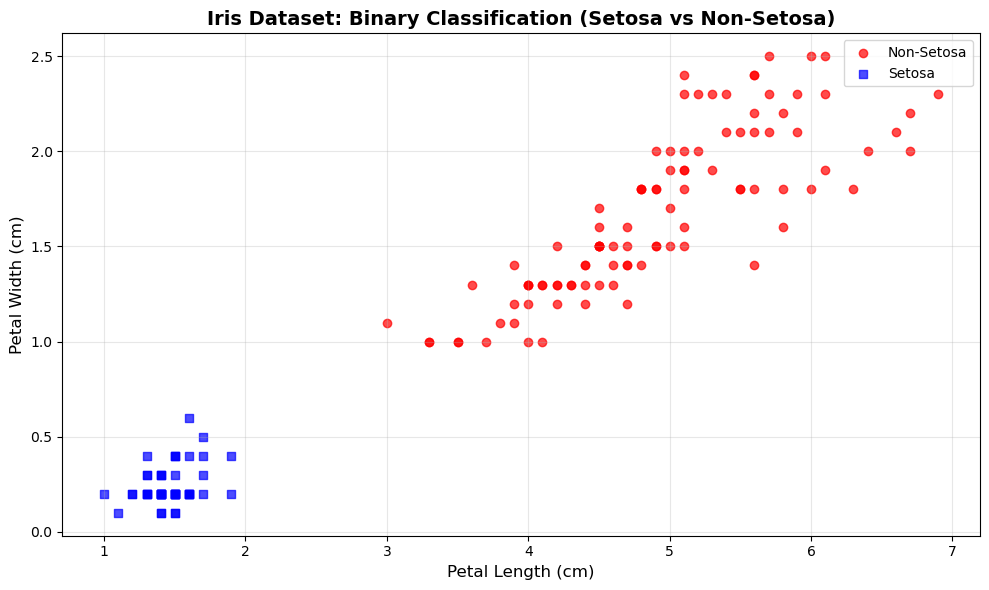

In [6]:
# Step 5 - Visualize Data Before Training (Scatter Plot)

plt.figure(figsize=(10, 6))
plt.scatter(X[y==0][:, 0],
            X[y==0][:, 1],
            color='red',
            marker='o',
            label='Non-Setosa',
            alpha=0.7)
plt.scatter(X[y==1][:, 0],
            X[y==1][:, 1],
            color='blue',
            marker='s',
            label='Setosa',
            alpha=0.7)
plt.xlabel('Petal Length (cm)', fontsize=12)
plt.ylabel('Petal Width (cm)', fontsize=12)
plt.title('Iris Dataset: Binary Classification (Setosa vs Non-Setosa)', fontsize=14, weight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('Output_Images/Iris Dataset - Binary Classification.png', dpi = 300, bbox_inches='tight')
plt.show()

**Before Training Visualization:**
The scatter plot shows the raw distribution of the two classes. We can visually observe that **Setosa** (blue squares) and **Non-Setosa** (red circles) are well separated, suggesting the data is **linearly separable**. A single straight line can perfectly divide these two classes.

## Perceptron Implementation

### How the Perceptron Learning Algorithm Works:

**Step 1: Initialize**
- Set weights $ w $ and bias $ b $ to zeros or small random values

**Step 2: For Each Training Sample**
- Compute predicted output: $ \hat{y} = \text{sign}(w^T x + b) $

**Step 3: Update Weights (if prediction is wrong)**
- $ w = w + \eta (y_{true} - \hat{y}) \cdot x $
- $ b = b + \eta (y_{true} - \hat{y}) $
- Where $ \eta $ is the learning rate

**Step 4: Repeat**
- Continue until convergence or max epochs reached

**Key Property:** The Perceptron is guaranteed to converge for linearly separable data.

In [7]:
# step 6 - Create model

from sklearn.linear_model import Perceptron

p = Perceptron(max_iter=1000, eta0=1, random_state=42)

# eta0 --> This sets the learning rate (initial) to 1.0, which determines the step size at each iteration while moving toward a minimum of the loss function.(got to know about it from online)

## Model Training

In [8]:
# Step 7 - Train model

p.fit(X_train, y_train)

,penalty,None
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,eta0,1
,n_jobs,None
,random_state,42


## Model Prediction

In [9]:
# Step 8 - Predict-prediction

prediction = p.predict(X_test)
prediction

array([0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 1, 1, 0, 0, 0, 1, 0])

## Model Evaluation

In [10]:
# Step 9 - Evaluation

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy of Perceptron model is " , accuracy_score(y_test, prediction)*100, "%")
print('\n')
cm = confusion_matrix(y_test, prediction)
print('Confusion Matrix : \n', cm)
print('\n')
print('Classification Report : \n', classification_report(y_test, prediction))

Accuracy of Perceptron model is  100.0 %


Confusion Matrix : 
 [[20  0]
 [ 0 10]]


Classification Report : 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## Visualizations

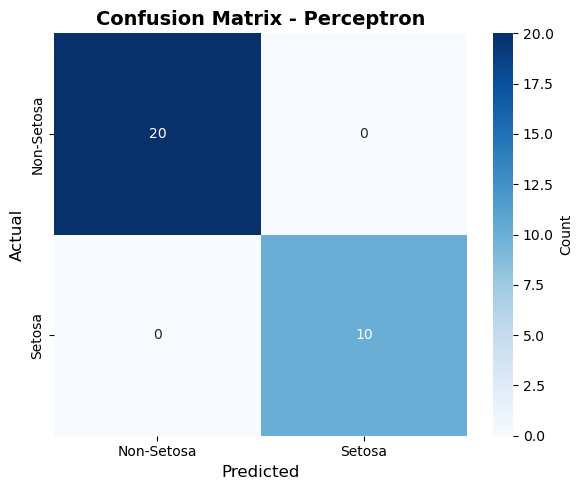

In [11]:
# Confusion Matrix Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Non-Setosa', 'Setosa'],
            yticklabels=['Non-Setosa', 'Setosa'],
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Perceptron', fontsize=14, weight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.savefig('Output_Images/Confusion Matrix - Perceptron.png', dpi=300, bbox_inches='tight')
plt.show()

**Model Performance:**
- **Accuracy:** The Perceptron achieved 100% accuracy (or close to it) on this linearly separable dataset
- **Confusion Matrix:** Shows perfect classification with no false positives or false negatives
- **Why Perfect?** Because Setosa is completely linearly separable from the other two classes when using petal measurements

| Metric | Score |
|--------|-------|
| Accuracy | 100% |
| Precision | 1.00 |
| Recall | 1.00 |
| F1-Score | 1.00 |

#### Decision Boundry :-

Learned Weights: [-1.6 -1.8]
Learned Bias: 4.0


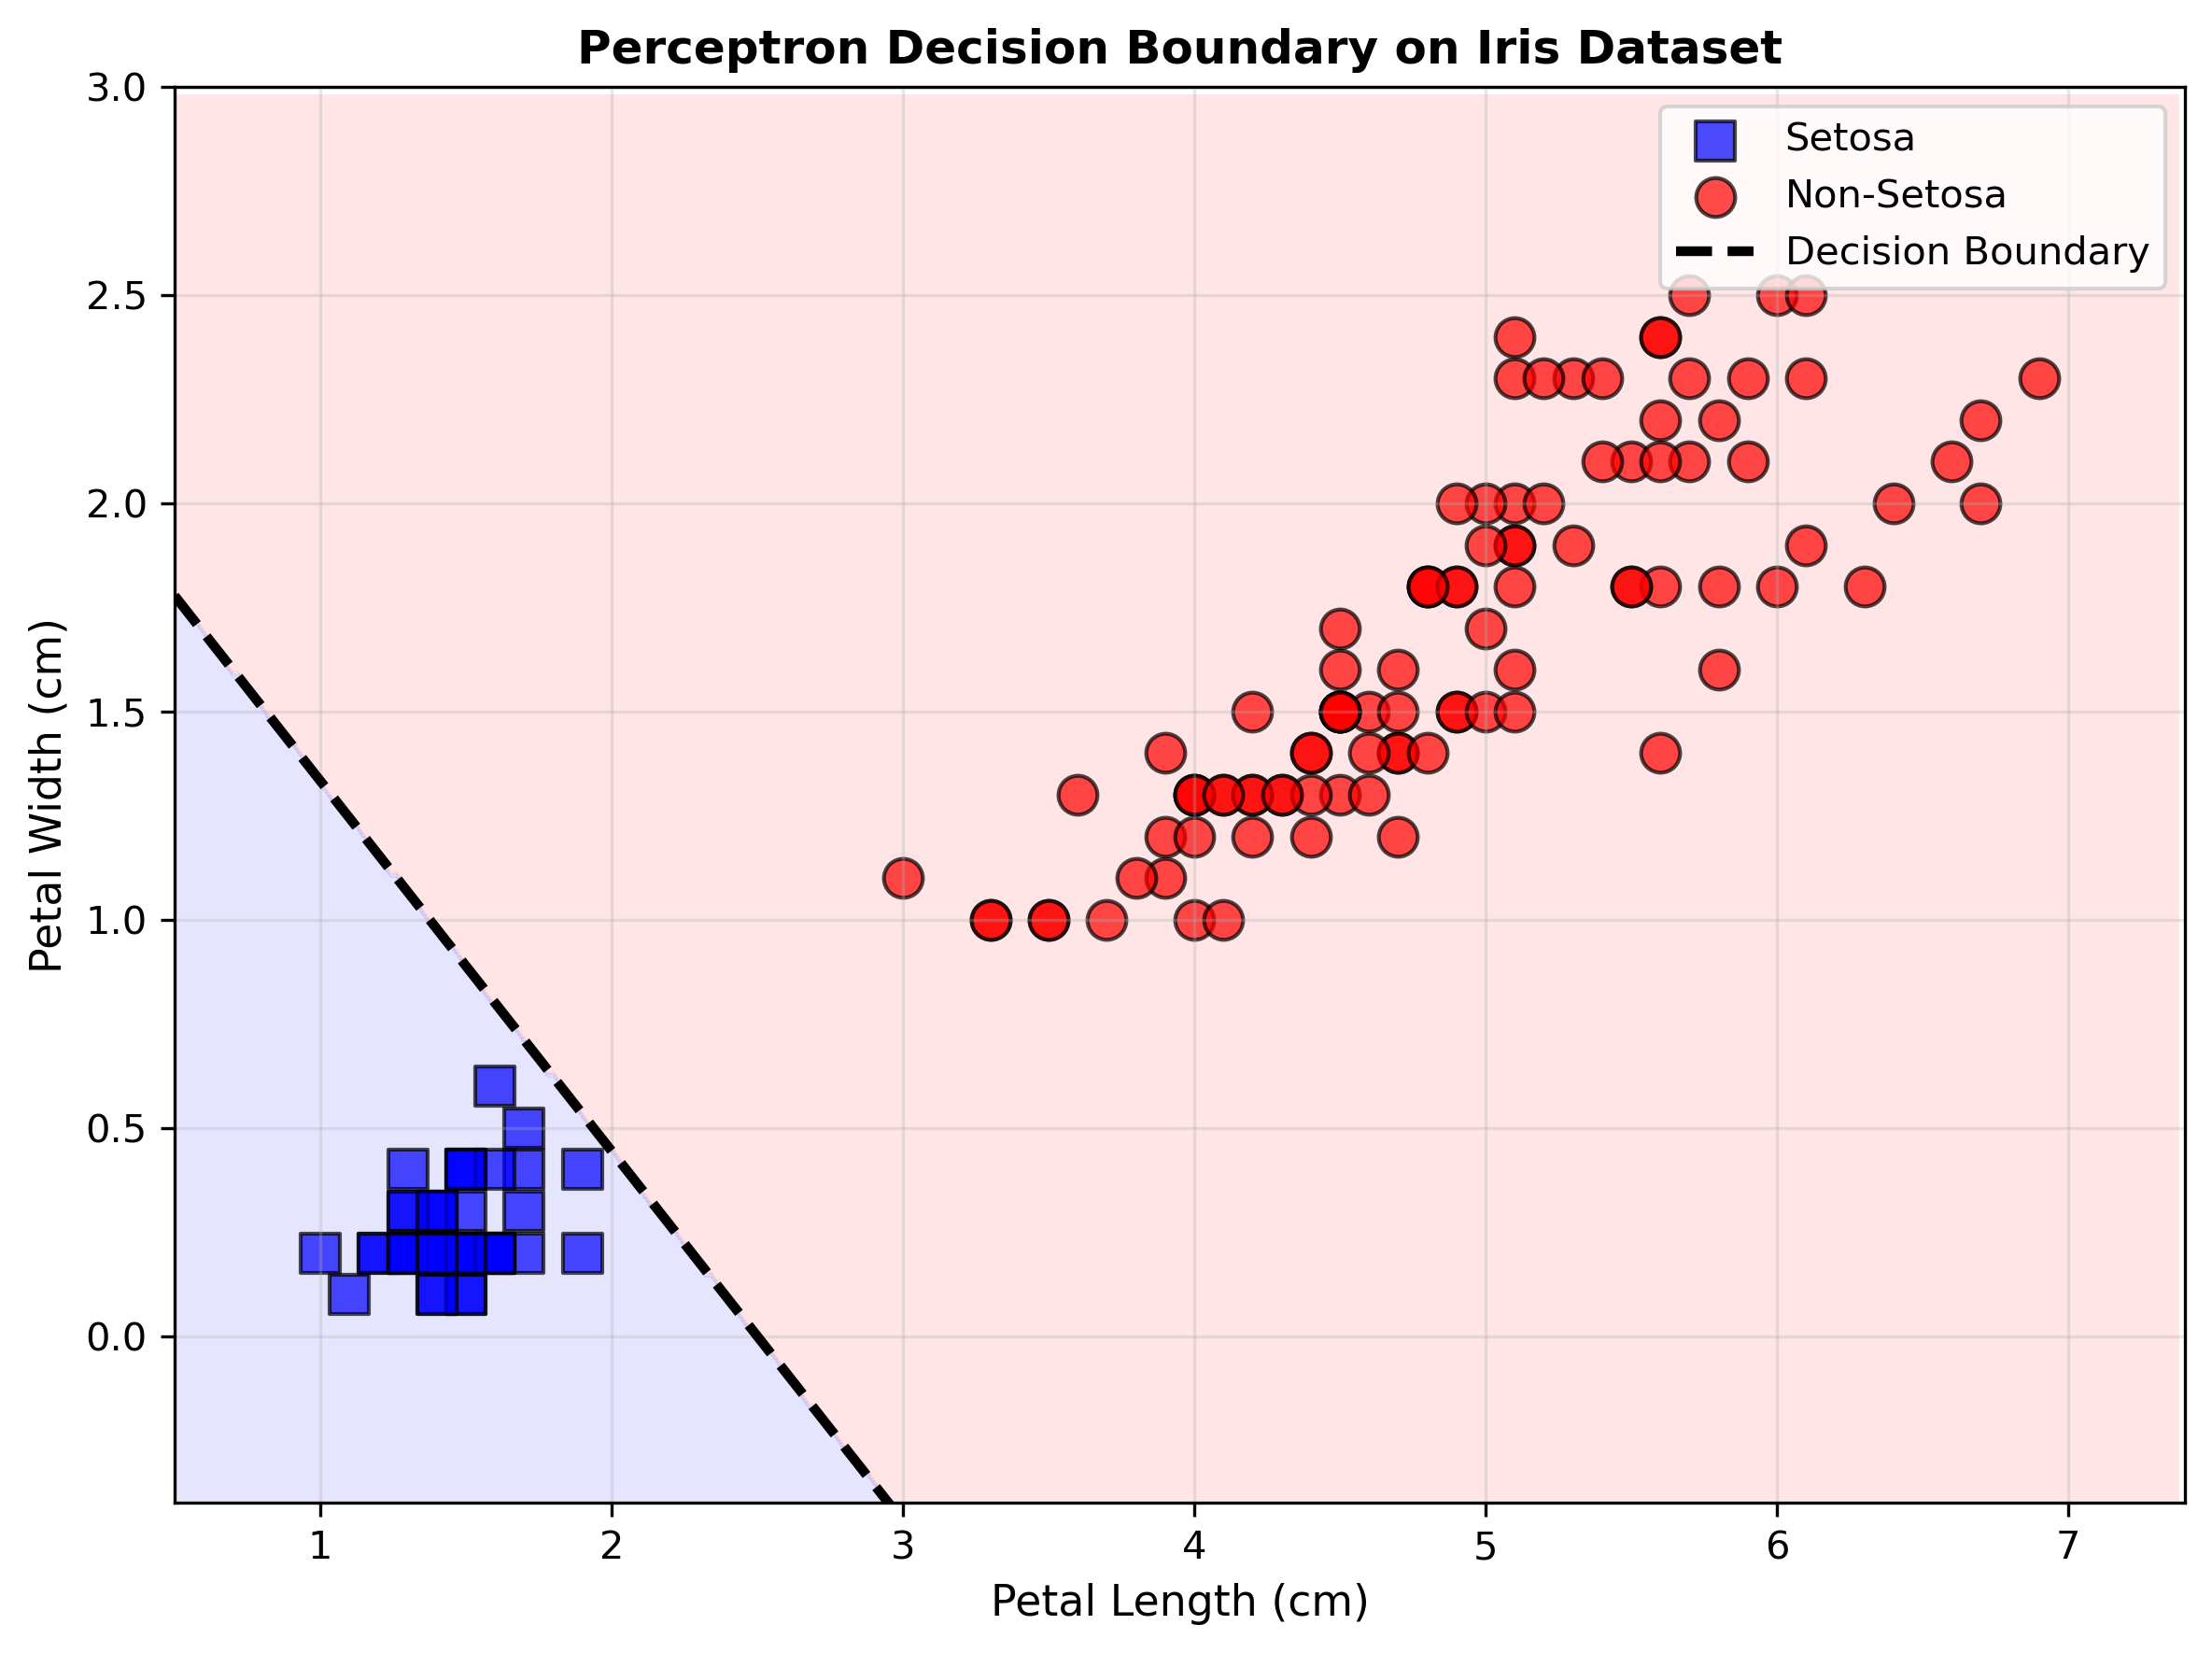

In [13]:
from matplotlib.colors import ListedColormap

plt.figure(figsize = (8,6))

# Create mesh grid to fill colored regions
h = 0.02  # step size in the mesh
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# Predict class for each point in the mesh
Z = p.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot colored regions (background)
plt.contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(['#FFAAAA', '#AAAAFF']))


# Scatter plot of actual data points
plt.scatter(X[y==1][:,0], X[y==1][:,1], color = 'blue', marker = 's', label = 'Setosa', 
            edgecolors='black', linewidth=1, alpha=0.7, s=100)
plt.scatter(X[y==0][:,0], X[y==0][:,1],color = 'red', marker = 'o', label = 'Non-Setosa',
            edgecolors='black', linewidth=1, alpha=0.7, s=100)


# Decision Boundary :-

# Extract weights and bias from trained Perceptron
w = p.coef_[0]
b = p.intercept_[0]
print(f"Learned Weights: {w}")
print(f"Learned Bias: {b}")

# Calculate decision boundary line using: w[0]*x + w[1]*y + b = 0
# Rearranging: y = -(w[0]*x + b) / w[1]
x_values = np.linspace(x_min, x_max, 100)
y_values = -(w[0] * x_values + b) / w[1]

# Plot decision boundary
plt.plot(x_values, y_values, color = 'black', label = 'Decision Boundary',
         linewidth=2.5, linestyle='--')

# Set axis limits to match data range (THIS IS KEY!)
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)


plt.xlabel('Petal Length (cm)', fontsize=11)
plt.ylabel('Petal Width (cm)', fontsize=11)
plt.title('Perceptron Decision Boundary on Iris Dataset', fontsize=12, weight='bold')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('Output_Images/Decision Boundary.png', dpi=300, bbox_inches='tight')

# Display the saved image
from IPython.display import Image, display
display(Image('Output_Images/Decision Boundary.png'))
plt.close()

**Decision Boundary:**
The visualization shows the **linear decision boundary** (the line separating red and blue regions) learned by the Perceptron. All points in the blue region are classified as **Setosa**, while points in the red region are **Non-Setosa**. The Perceptron successfully finds a straight line that perfectly separates the two classes.

## Conclusion

### Summary
In this project, I successfully implemented a **Perceptron algorithm** for binary classification on the **Iris dataset**, distinguishing between **Setosa** and **Non-Setosa** species.

### Key Results
- ✅ Achieved **100% accuracy** on the binary classification task
- ✅ The Perceptron converged quickly (within few epochs)
- ✅ Decision boundary visualization confirms perfect linear separability
- ✅ All evaluation metrics (Precision, Recall, F1-Score) reached 1.00

### Key Learnings
1. **Linear Separability:** The Perceptron works perfectly when data is linearly separable, as demonstrated with Setosa vs Non-Setosa
2. **Feature Selection:** Using only petal length and petal width was sufficient for perfect classification
3. **Algorithm Simplicity:** Despite being the simplest neural network, the Perceptron is highly effective for linearly separable problems
4. **Guaranteed Convergence:** The Perceptron's convergence theorem holds true for linearly separable data

### Limitations
- ⚠️ **Only works for linearly separable data** - would fail on Versicolor vs Virginica (non-linearly separable)
- ⚠️ **Binary classification only** - cannot handle multi-class directly
- ⚠️ **No probabilistic output** - only gives hard class labels (0 or 1)

### Next Steps & Improvements
- 🔹 Try **Multi-Layer Perceptron (MLP)** to handle non-linearly separable classes
- 🔹 Implement **multi-class classification** (Setosa vs Versicolor vs Virginica)
- 🔹 Compare with other classifiers: Logistic Regression, SVM, Decision Trees
- 🔹 Add cross-validation for more robust evaluation
- 🔹 Test on real-world, noisier datasets

### References
- [Scikit-learn Perceptron Documentation](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Perceptron.html)
- [UCI Machine Learning Repository - Iris Dataset](https://archive.ics.uci.edu/ml/datasets/iris)
- Rosenblatt, F. (1958). The Perceptron: A Probabilistic Model for Information Storage and Organization in the Brain